# Cream Cheese Fermentation

This notebook contains the research and development of a model to simulate the cream cheese fermentation process. The model is based on a system of differential equations that describe the dynamics of the fermentation process.

This is a mock model that is not based on real data. It is intended to be used as a reference for the development of a real model.

## Dependencies
- [MLFlow](https://mlflow.org/) 

MlFlow needs to be installed and running in order to register any model. Please refer to the [Models README.md](../README.md) file for instructions on how to install and run MLFlow.

## Workflow
Usually creating a model involves the following steps:

1. Research and development
2. Model definition
3. Experiment registration
4. Model running, logging metrics and evaluation
5. Model publishing

### Research and Development

Research and development is the first step in creating a model. It involves understanding the problem, collecting data, and developing a mathematical model that describes the system. It can be done using a Jupyter notebook, which allows for interactive exploration and visualization of the data and model.

The [Cream Cheese Fermentation Paper](cream_cheese_fermentation_paper.ipynb) describes a mathematical model for the fermentation process of cream cheese. The model consists of a system of ordinary differential equations (ODEs) that describe the dynamics of bacterial concentration, lactic acid concentration, and pH values over time.


### Model Definition
The research is formalized into a Python class that can be registered with MLFlow. In this case the model can be found at:

- [cream_cheese_fermentation_model.py](cream_cheese_fermentation_model.py)

### Experiment Registration
In MLFlow, an experiment is a collection of runs that are related to a specific model or project. Each run represents a single execution of the model with a specific set of parameters and inputs. So, beore logging the model, we need to register an experiment in MLFlow. This can be done using the MLFlow API or the MLFlow UI.

In [15]:
import mlflow
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment(experiment_name="cream-cheese-fermentation-ode")

<Experiment: artifact_location='/Users/diegolopezronda/Documents/github/fonterra-SWE-assessment/models/mlflow/artifacts/1', creation_time=1784474512347, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1784474512347, lifecycle_stage='active', name='cream-cheese-fermentation-ode', tags={}, trace_location=None, workspace='default'>

### Running the model
Running the model involves executing the model with a specific set of parameters and inputs. This can be done using the MLFlow API or the MLFlow UI. The results of the run can be logged to MLFlow for later analysis and evaluation.

Every time the model is run, a new run record is created in the MLFlow experiment. Each run can be associated with a model. When a run is executed, the model version is updated. The idea is to be able to version control over the model and confidently experiment with different parameters and inputs and formulas. This is especially useful when the model is being developed and improved over time.

In [3]:
# Let's define our inputs
x0 = 10e6
p0 = 10e-6
mu = 1.0
q = -16.0
c1 = 5.0
c2 = 12.0
# These are the hyperparameters of the model.
params = {"x0": x0, "p0": p0, "t_start": 0, "t_end": 12, "t_steps": 1000}
# These are the (kinetic) parameters of the model.
model_input = {"c1": c1, "c2": c2, "mu": mu, "q": q}
# This is the combination of both hyperparameters and parameters.
all_params = params | model_input
# Model description
model_name = "cream-cheese-fermentation-ode"
model_description = "Cream Cheese Fermentation ODE Model Run."
model_tags = {
    "project": "cream-cheese",
    "model_type": "ODE",
    "environment": "dev",
    "owner": "data-science-team",
}

/Users/diegolopezronda/Documents/github/fonterra-SWE-assessment/models/.venv/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


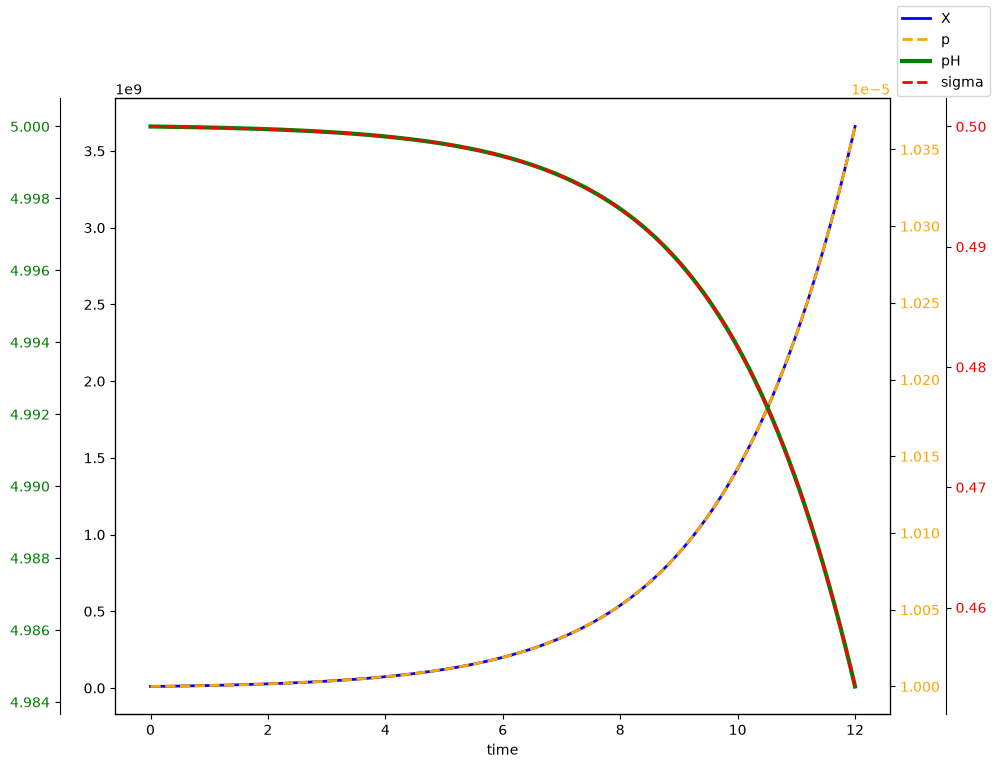

In [4]:
from cream_cheese_fermentation_model import CreamCheeseFermentationModel
from plotter import plot
# Run the model
results = CreamCheeseFermentationModel().predict(
    context=None, model_input=model_input, params=params
)
plot(results)

In [5]:
from mlflow.models import infer_signature

# Create signature (inputs/output schema) for the model
signature = infer_signature(
    model_input=model_input, model_output=results, params=params
)

In [20]:
run_id = None
with mlflow.start_run(description=model_description) as run:
    # Associate the run with our model
    # This will create a new version of the model in the MLFlow model registry
    mlflow.pyfunc.log_model(
        name="cream_cheese_fermentation_model",
        python_model="cream_cheese_fermentation_model.py",
        registered_model_name=model_name,
        input_example=model_input,
        params=params
    )
    # Add tags to the run for better organization and searchability
    mlflow.set_tags(model_tags)
    # Automatically log parameters, metrics, and models for supported libraries
    mlflow.autolog()
    # Log hyperparameters and parameters
    mlflow.log_params(all_params)
    # Log each series in the results DataFrame as a separate metric
    for step, row in results.iterrows():
        for col_name, value in row.items():
            mlflow.log_metric(key=col_name, value=value, step=int(step))
    # Log the results DataFrame as an artifact
    mlflow.log_table(data=results, artifact_file="results.json")
    print(f"Simulation Finished!")
    run_id = run.info.run_id

/Users/diegolopezronda/Documents/github/fonterra-SWE-assessment/models/.venv/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/07/20 08:32:37 INFO mlflow.pyfunc: Inferring model signature from input example
/Users/diegolopezronda/Documents/github/fonterra-SWE-assessment/models/.venv/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
Registered model 'cream-cheese-fermentation-ode' already exists. Creating a new version of th

Simulation Finished!
🏃 View run intrigued-grub-509 at: http://127.0.0.1:5000/#/experiments/1/runs/bf91a81d75ed48d88e19036e271bd9c5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Calling the model using MLFlow Python API

/Users/diegolopezronda/Documents/github/fonterra-SWE-assessment/models/.venv/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


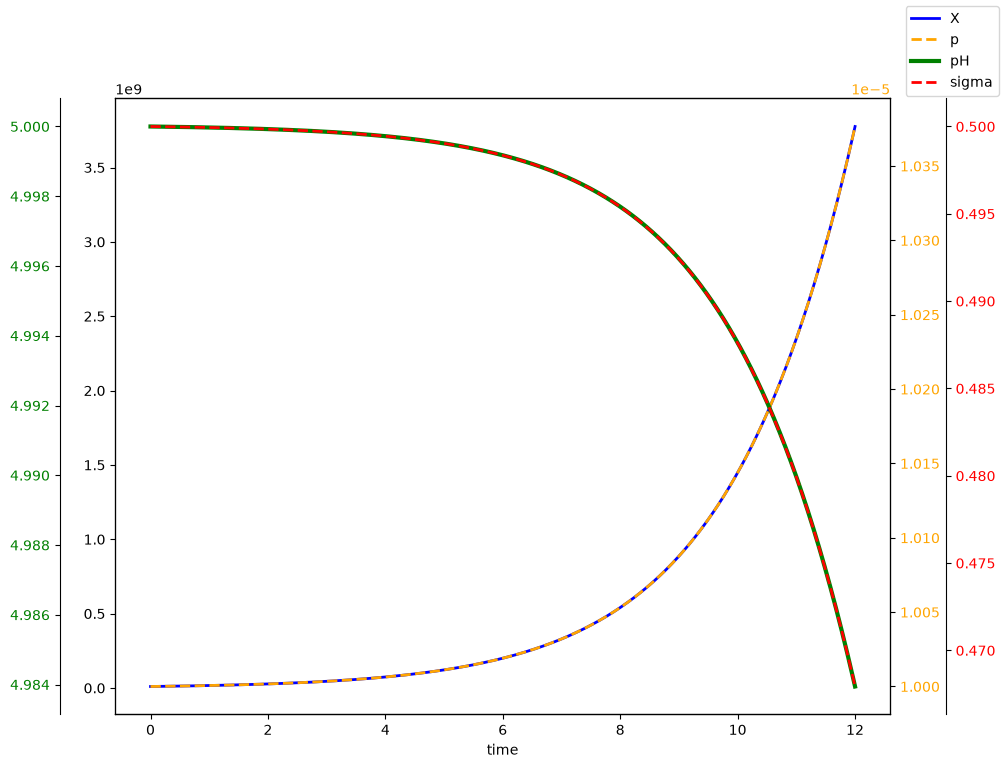

In [25]:
loaded_model = mlflow.pyfunc.load_model(
    f"models:/{model_name}/latest"
)

x0 = 10e6
p0 = 10e-6
mu = 1.0
q = -16.0
c1 = 5.0
c2 = 8.0
predict_params = {
    "model_input": {"c1": c1, "c2": c2, "mu": mu, "q": q},
    "params": {"y0": [x0, p0], "t_start": 0.0, "t_end": 12, "t_steps": 1000},
}

results = loaded_model.predict(predict_params["model_input"])
plot(results)

## Calling the model using MLFlow REST API

To enable external access to the model, we can use the MLFlow REST API. To serve the model we can use the following command:

In [59]:
%%sh
MODEL_NAME="cream-cheese-fermentation-ode"
MODEL_VERSION=latest
PORT=8001
mlflow models serve -m "models:/$MODEL_NAME/$MODEL_VERSION" --port $PORT --env-manager local >/dev/null 2>&1 &
echo $! > model_endpoint_pid

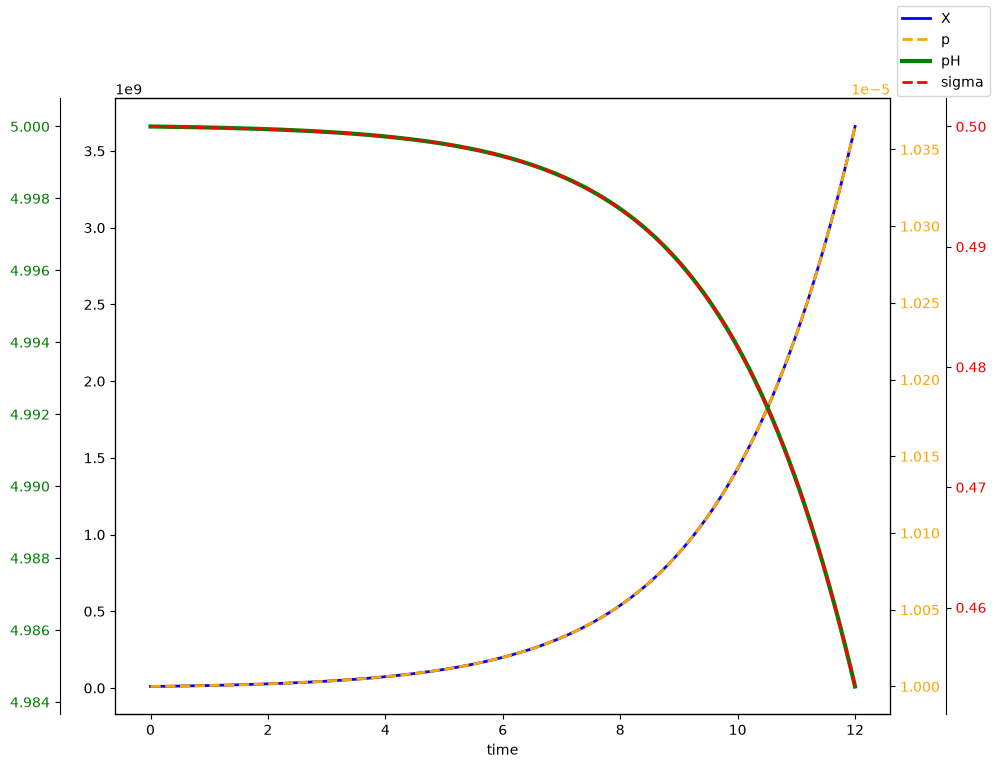

In [50]:
import requests
import pandas as pd

port = 8001
url = f"http://127.0.0.1:{port}/invocations"

x0 = 10e6
p0 = 10e-6
mu = 1.0
q = -16.0
c1 = 5.0
c2 = 12.0

predict_params = {
    "dataframe_records": [{"c1": c1, "c2": c2, "mu": mu, "q": q}],
    "params": {"y0": [x0, p0], "t_start": 0.0, "t_end": 12, "t_steps": 1000},
}

response = requests.post(url, json=predict_params)
if response.status_code == 200:
    predictions = response.json()["predictions"]
    df_results = pd.DataFrame(predictions)
    plot(df_results)
else:
    print(f"Request failed with status code: {response.status_code}")
    print(f"Response content: {response.text}")

# Stopping the model API endpoint

In [61]:
%%sh
kill "$(cat model_endpoint_pid)"
rm model_endpoint_pid

sh: line 1: kill: (42933) - No such process
